## 🏆 도전 문제 (심화)

1. **도전 1**: 미로 크기를 10×10으로 늘리고 벽을 랜덤하게 생성하여 BFS로 최단경로를 구하세요.
2. **도전 2**: 경사하강법에 **모멘텀(Momentum)** 을 추가하여 수렴 속도를 개선하세요.  
   `v = β·v + (1-β)·∇J`,  `θ = θ - α·v`
3. **도전 3**: Lasso 회귀에서 선택된 특성만 사용한 모델과 모든 특성을 사용한 모델을 R²로 비교하세요.

In [50]:
# ─── 필요한 라이브러리 임포트 ───────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import deque

# scikit-learn
from sklearn.datasets import load_diabetes, make_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

# 한글 폰트 및 마이너스 기호 설정 (Windows 환경)
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.family'] = 'Malgun Gothic'

print('✅ 라이브러리 로드 완료')

✅ 라이브러리 로드 완료


=== 미로 지도 (0: 길, 1: 벽) ===
[[0 0 0 1 0 0 0 0 0 0]
 [0 0 0 1 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 1 0 0]
 [0 1 1 0 0 0 0 0 0 1]
 [0 1 0 0 0 1 0 0 0 0]
 [0 0 0 0 1 0 0 0 0 0]
 [0 1 1 0 0 0 1 1 0 0]
 [0 0 0 0 0 1 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 1 0 0 0 0]]

✅ 탈출 성공! 최단경로 길이: 18칸 이동
경로: [(0, 0), (0, 1), (0, 2), (1, 2), (2, 2), (2, 3), (2, 4), (2, 5), (2, 6), (3, 6), (3, 7), (3, 8), (4, 8), (4, 9), (5, 9), (6, 9), (7, 9), (8, 9), (9, 9)]


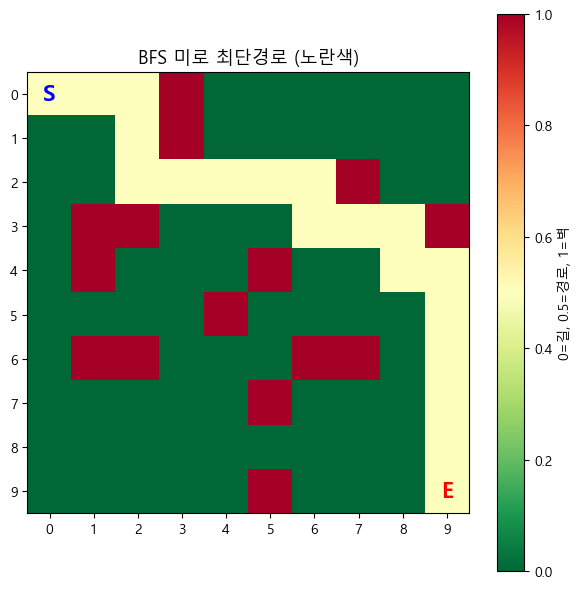

In [51]:
# 1. 미로 크기 10×10, 랜덤 벽 생성 후 BFS로 최단경로 구하기
# bfs_maze 함수 정의
def bfs_maze(maze, start, end):
    """
    2D 미로 BFS 탐색
    0 = 이동 가능, 1 = 벽
    """
    rows, cols = len(maze), len(maze[0])
    directions = [(0,1),(0,-1),(1,0),(-1,0)]  # 우좌하상 #

    visited = {start}
    queue   = deque([(start, [start])]) # 좌표, 발자취 경로
    
    while queue:
        (r, c), path = queue.popleft() # 큐에서 현재 위치(r, c)와 
                                       # 발자취(path)를 분리해서 꺼냄
        if (r, c) == end:
            return path
        
        for dr, dc in directions: # dr:r value, dc:c value // 상하좌우 4방향 이동 시도
            nr, nc = r+dr, c+dc
            if 0<=nr<rows and 0<=nc<cols and maze[nr][nc]==0 and (nr,nc) not in visited:
                visited.add((nr, nc))
                queue.append(((nr, nc), path + [(nr, nc)]))
    
    return None # 큐를 다 비웠는데도 end에 도착하지 못하면 길이 없는 것

# 10 x 10 랜덤 미로 생성, 시작과 끝은 통로 확보[0]
maze = np.random.choice([0, 1], size=(10, 10), p=[1-0.2, 0.2])
maze[0, 0] = 0
maze[9, 9] = 0
    
start, end = (0, 0), (9, 9)
path = bfs_maze(maze, start, end)

# 결과 출력
print("=== 미로 지도 (0: 길, 1: 벽) ===")
print(maze)
if path:
    print(f"\n✅ 탈출 성공! 최단경로 길이: {len(path)-1}칸 이동")
    print(f"경로: {path}")
else:
    print("\n❌ 탈출 불가! 랜덤 생성된 벽들로 인해 출구가 완전히 막혔습니다.")

# 시각화
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
maze_arr = np.array(maze, dtype=float)

# 경로 표시
if path:
    for r, c in path:
        maze_arr[r][c] = 0.5

ax.imshow(maze_arr, cmap='RdYlGn_r', vmin=0, vmax=1)
ax.text(start[1], start[0], 'S', ha='center', va='center', fontsize=16, fontweight='bold', color='blue')
ax.text(end[1],   end[0],   'E', ha='center', va='center', fontsize=16, fontweight='bold', color='red')
ax.set_xticks(range(10))
ax.set_yticks(range(10))
ax.set_title('BFS 미로 최단경로 (노란색)', fontsize=13)
plt.colorbar(ax.images[0], ax=ax, label='0=길, 0.5=경로, 1=벽')
plt.tight_layout()
plt.show()

데이터 형태: (442, 10)
특성 이름: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
타깃 범위: 25.0 ~ 346.0

정규화된 훈련 샘플: [1.49836523 1.06136988 0.21990201] / 정규화된 테스트 샘플: [ 0.94879413 -0.94217861 -0.16822504]

훈련 샘플: 353 / 테스트 샘플: 89


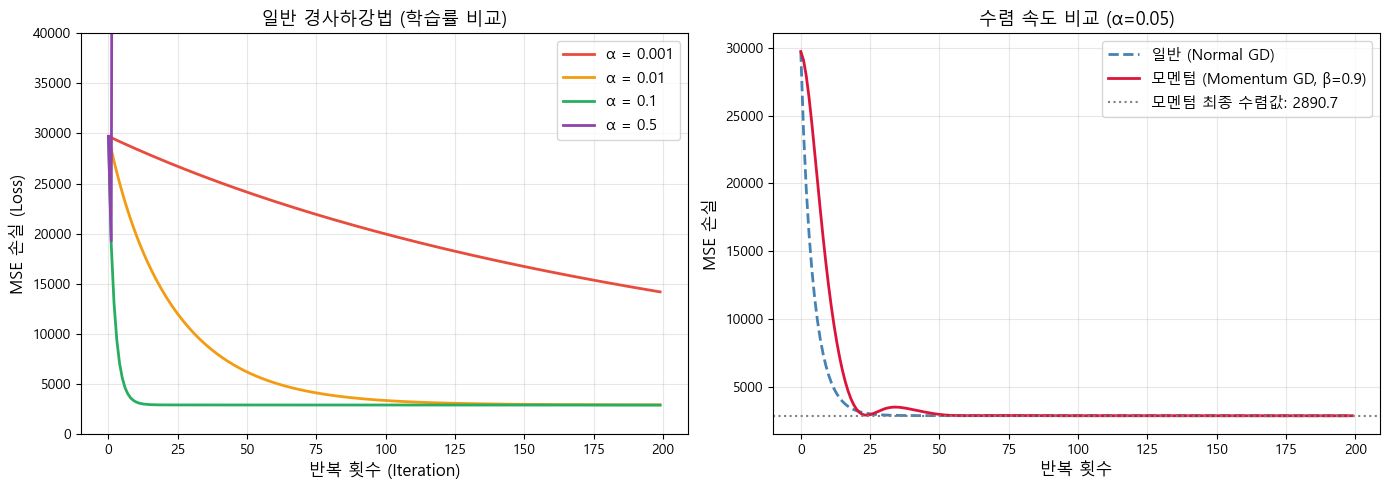


최적화된 일반 GD θ (처음 5개):  [153.74   1.94 -11.43  26.27  16.61]
최적화된 모멘텀 GD θ (처음 5개): [153.74   1.94 -11.43  26.27  16.61]


In [52]:
# 2. 경사하강법에 **모멘텀(Momentum)** 을 추가하여 수렴 속도를 개선하세요.  
#   `v = β·v + (1-β)·∇J`,  `θ = θ - α·v`

# 데이터 로드
diabetes = load_diabetes()
X = diabetes.data        # (442, 10) - 10개 특성
y = diabetes.target      # (442,)    - 연속값 (당뇨 진행 지수)

print('데이터 형태:', X.shape)
print('특성 이름:', diabetes.feature_names)
print('타깃 범위: {:.1f} ~ {:.1f}'.format(y.min(), y.max()))

# 훈련/테스트 분리 (8:2)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 스케일링 (훈련 기준으로 변환)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
print('\n정규화된 훈련 샘플:', X_train_scaled[0, :3], '/ 정규화된 테스트 샘플:', X_test_scaled[0, :3])


print('\n훈련 샘플:', X_train.shape[0], '/ 테스트 샘플:', X_test.shape[0])

# 배치경사하강법 정의
def gradient_descent(X, y, alpha=0.01, n_iter=1000):
    """
    배치 경사하강법 (Batch Gradient Descent)
    X: 특성 행렬, y: 타깃, alpha: 학습률, n_iter: 반복 횟수
    """
    m, n = X.shape
    # 편향 추가
    X_b = np.hstack([np.ones((m, 1)), X])
    theta = np.zeros(n + 1)  # 파라미터 초기화
    loss_history = []
    
    for i in range(n_iter):
        # 예측
        y_pred = X_b @ theta
        # 오차
        error = y_pred - y
        # MSE 손실
        loss = (1 / m) * np.sum(error ** 2)
        loss_history.append(loss)
        # 기울기(gradient) 계산
        gradient = (2 / m) * X_b.T @ error
        # 파라미터 업데이트
        theta -= alpha * gradient
    
    return theta, loss_history

# 모멘텀 추가 배치 경사하강법 정의
def gradient_descent_momentum(X, y, alpha=0.01, beta=0.9, n_iter=1000):
    """
    모멘텀 추가된 배치 경사하강법 (Batch Gradient Descent)
    X: 특성 행렬, y: 타깃, alpha: 학습률, beta: 모멘텀 계수, n_iter: 반복 횟수
    """
    m, n = X.shape
    # 편향 추가
    X_b = np.hstack([np.ones((m, 1)), X])
    theta = np.zeros(n + 1)  #  파라미터 초기화
    v = np.zeros(n+1) # 초기 속도(관성) 0으로 세팅
    loss_history = []
    
    for i in range(n_iter):
        # 예측
        y_pred = X_b @ theta
        # 오차
        error = y_pred - y
        # MSE 손실
        loss = (1 / m) * np.sum(error ** 2)
        loss_history.append(loss)
        # 기울기(gradient) 계산
        gradient = (2 / m) * X_b.T @ error
        # 모멘텀 업데이트 적용
        v = beta * v + (1 - beta) * gradient
        # 파라미터 업데이트
        theta -= alpha * v
    
    return theta, loss_history


# 학습률별 비교
alpha_test = 0.05
n_iter_test = 200
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# [왼쪽 축] 일반 경사하강법
# 학습률별 비교
alphas = [0.001, 0.01, 0.1, 0.5]
colors = ['#e74c3c', '#f39c12', '#27ae60', '#8e44ad']

for alpha_val, color in zip(alphas, colors):
    theta, losses = gradient_descent(X_train_scaled, y_train, alpha=alpha_val, n_iter=n_iter_test)
    axes[0].plot(losses, label=f'α = {alpha_val}', color=color, lw=2)

axes[0].set_xlabel('반복 횟수 (Iteration)', fontsize=12)
axes[0].set_ylabel('MSE 손실 (Loss)', fontsize=12)
axes[0].set_title('일반 경사하강법 (학습률 비교)', fontsize=13)
axes[0].legend(fontsize=11)
axes[0].set_ylim(0, 40000)
axes[0].grid(True, alpha=0.3)


# [오른쪽 축] 일반 vs 모멘텀 수렴 속도 비교
# 일반 경사하강법 학습
theta_normal, losses_normal = gradient_descent(
    X_train_scaled, y_train, alpha=alpha_test, n_iter=n_iter_test
)

# 모멘텀 경사하강법 학습 (beta = 0.9 적용)
theta_momentum, losses_momentum = gradient_descent_momentum(
    X_train_scaled, y_train, alpha=alpha_test, beta=0.9, n_iter=n_iter_test
)
axes[1].plot(losses_normal, label='일반 (Normal GD)', color='steelblue', lw=2, linestyle='--')
axes[1].plot(losses_momentum, label='모멘텀 (Momentum GD, β=0.9)', color='crimson', lw=2)
axes[1].axhline(y=losses_momentum[-1], color='gray', linestyle=':', lw=1.5,
                label=f'모멘텀 최종 수렴값: {losses_momentum[-1]:.1f}')
axes[1].set_xlabel('반복 횟수', fontsize=12)
axes[1].set_ylabel('MSE 손실', fontsize=12)
axes[1].set_title(f'수렴 속도 비교 (α={alpha_test})', fontsize=13)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'\n최적화된 일반 GD θ (처음 5개):  {theta_normal[:5].round(2)}')
print(f'최적화된 모멘텀 GD θ (처음 5개): {theta_momentum[:5].round(2)}')

<<그래프 분석>>
1. 초반에 모멘텀(빨간 실선)이 일반(파란 점선)보다 더 천천히 감소
2. 모멘텀 최적점(바닥)에 도달할 즈음 다시 손실(MSE)이 살짝 튀어 오르는 '꿀렁임(Overshooting)'이 발생함

-->> 모멘텀 업데이트 수식  v = beta * v + (1 - beta) * gradient이고 beta=0.9이므로 첫 스텝에서 실제 기울기의 10%를 이동하게 됨. 반면 일반은 처음부터 기울기의 100%를 학습률에 곱해 이동하므로 모멘텀이 속도가 상대적으로 천천히 붙은 것으로 결과 현출

-->> 모멘텀은 최적점에 도착한 후에도 관성이 남아 있기 때문에 정지하지 못하고 지나쳤다가 다시 최종적으로 바닥에 안착한 것으로 보임. 따라서 단순한 학습에서는 일반 경사하강법이 더 유리하고, 복잡한 학습의 경우 지역최저점을 탈출할 수 있는 모멘텀 경사하강법이 더 유리할 것으로 판단

=== 1. 모든 특성(10개)을 사용한 선형회귀 모델 ===
R² 스코어 : 0.4526
MSE       : 2900.2

=== 2. 람다(λ) 값 변화에 따른 특성 선택 및 Lasso 모델 성능 비교 ===
Lambda   | 생존 특성 수  | R² 스코어   | MSE        | 살아남은 특성 목록
------------------------------------------------------------------------------------------
λ = 0.1  | 10개         | 0.4526     | 2900.2     | ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
λ = 1.0  |  9개         | 0.4526     | 2900.3     | ['age', 'sex', 'bmi', 'bp', 's1', 's3', 's4', 's5', 's6']
λ = 5.0  |  5개         | 0.4694     | 2811.4     | ['sex', 'bmi', 'bp', 's3', 's5']
λ = 10.0 |  4개         | 0.4470     | 2929.8     | ['bmi', 'bp', 's3', 's5']

=== 3. 최적 모델 비교 (일반 선형 모델 vs 최적 Lasso 모델) ===
일반 모델(특성 10개) R²: 0.4526  |  최적 Lasso(λ=5.0, 특성 5개) R²: 0.4694


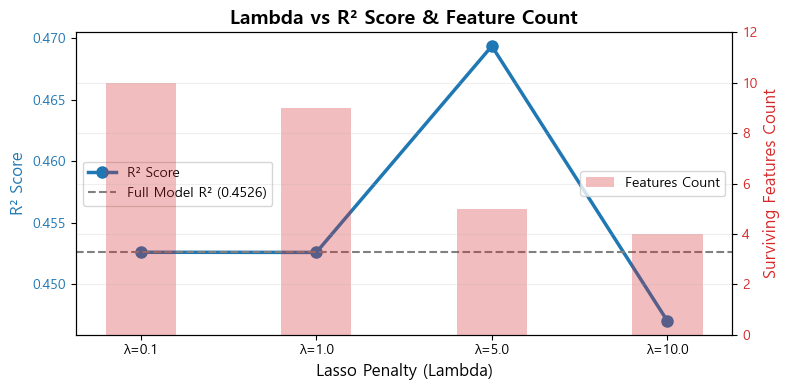


=== 4. 최종 분석 결과 ===
👉 람다(λ)가 커질수록 생존하는 특성 개수가 감소, 람다값이 0.5일 때 최고 성능
👉 특정 람다값(예: 1.0)에서는 특성을 줄였음에도 R²가 거의 동일하게 유지되어 '모델 경량화'에 성공
👉 람다가 커지면 모델의 성능이 향상되기도 하지만 너무 커지면(예: 10.0) 중요한 정보까지 없어져 성능이 뚜렷하게 하락


In [53]:
# 3. Lasso 회귀에서 선택된 특성만 사용한 모델과 모든 특성을 사용한 모델을 R²로 비교하세요.
# 1. 모든 특성을 사용한 선형회귀 모델
lr_f = LinearRegression()
lr_f.fit(X_train_scaled, y_train)
pred_f = lr_f.predict(X_test_scaled)
r2_f = r2_score(y_test, pred_f)
mse_f = mean_squared_error(y_test, pred_f)
print("=== 1. 모든 특성(10개)을 사용한 선형회귀 모델 ===")
print(f"R² 스코어 : {r2_f:.4f}")
print(f"MSE       : {mse_f:.1f}\n")


# 2. 람다(alpha) 변화에 따른 Lasso 특성 선택 및 모델 평가
# 테스트할 람다값 리스트와 원본 특성 이름 가져오기
lambda_values = [0.1, 1.0, 5.0, 10.0]
feature_names = diabetes.feature_names

# 최적의 모델을 찾기 위한 추적 변수 생성
best_r2 = -float('inf')
best_lambda = None
best_features_cnt = 0

# 데이터 리스트
plot_lambdas = []
plot_r2 = []
plot_features_cnt = []

print("=== 2. 람다(λ) 값 변화에 따른 특성 선택 및 Lasso 모델 성능 비교 ===")
print(f"{'Lambda':<8} | {'생존 특성 수':<8} | {'R² 스코어':<8} | {'MSE':<10} | 살아남은 특성 목록")
print("-" * 90)
for alpha_val in lambda_values:
    
    # Lasso 모델로 특성 솎아내기
    lasso_s = Lasso(alpha=alpha_val, max_iter=10000)
    lasso_s.fit(X_train_scaled, y_train)
    
    # 가중치가 0.001 이상인 특성 인덱스만 추출
    selected_indices = np.where(np.abs(lasso_s.coef_) > 0.001)[0]
    
    # 만약 람다값이 너무 커서 모든 특성이 0이 되어버리면 모델 학습이 불가하므로 예외 처리
    if len(selected_indices) == 0:
        print(f"λ = {alpha_val:<4} | {'0개 (전부사망)':<10} | {'-':<10} | {'-':<10} | 없음")
        continue
        
    selected_features = [feature_names[i] for i in selected_indices]
    
    # 선택된 특성만 가져와서 새로운 데이터셋 구성
    X_train_selected = X_train_scaled[:, selected_indices]
    X_test_selected = X_test_scaled[:, selected_indices]
    
    # 새로운 데이터로 선형 회귀 학습 및 평가
    lr_s = LinearRegression()
    lr_s.fit(X_train_selected, y_train)
    pred_s = lr_s.predict(X_test_selected)
    
    r2_s = r2_score(y_test, pred_s)
    mse_s = mean_squared_error(y_test, pred_s)
    
    # 현재 람다값의 R²가 기존 최고 R²보다 높다면 최고 기록 갱신
    if r2_s > best_r2:
        best_r2 = r2_s
        best_lambda = alpha_val
        best_features_cnt = len(selected_features)
    
    plot_lambdas.append(f"λ={alpha_val}")
    plot_r2.append(r2_s)
    plot_features_cnt.append(len(selected_features))

    # 결과 출력
    print(f"λ = {alpha_val:<4} | {len(selected_features):2d}개{'':<8} | {r2_s:.4f}{'':<4} | {mse_s:.1f}{'':<4} | {selected_features}")


# 3. 최적 람다값 기반 결과 요약 출력
print("\n=== 3. 최적 모델 비교 (일반 선형 모델 vs 최적 Lasso 모델) ===")
print(f"일반 모델(특성 10개) R²: {r2_f:.4f}  |  최적 Lasso(λ={best_lambda}, 특성 {best_features_cnt}개) R²: {best_r2:.4f}")


# 4. 시각화 (그래프 그리기)
fig, ax1 = plt.subplots(figsize=(8, 4))

# 왼쪽 Y축: R² 스코어 (파란색 꺾은선 그래프)
color1 = 'tab:blue'
ax1.set_xlabel('Lasso Penalty (Lambda)', fontsize=12)
ax1.set_ylabel('R² Score', color=color1, fontsize=12)
line1 = ax1.plot(plot_lambdas, plot_r2, color=color1, marker='o', linewidth=2.5, markersize=8, label='R² Score')
ax1.tick_params(axis='y', labelcolor=color1)

# 기준선: 모든 특성을 사용한 일반 선형 모델의 R²
line2 = ax1.axhline(y=r2_f, color='gray', linestyle='--', linewidth=1.5, label=f'Full Model R² ({r2_f:.4f})')

# 오른쪽 Y축: 생존 특성 수 (빨간색 막대 그래프)
ax2 = ax1.twinx()  
color2 = 'tab:red'
ax2.set_ylabel('Surviving Features Count', color=color2, fontsize=12)  
bar1 = ax2.bar(plot_lambdas, plot_features_cnt, color=color2, alpha=0.3, width=0.4, label='Features Count')
ax2.tick_params(axis='y', labelcolor=color2)
ax2.set_ylim(0, 12) # 특성이 최대 10개이므로 여유있게 12로 설정

# 범례(Legend) 합치기
lines = line1 + [line2]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='center left')
ax2.legend([bar1], [bar1.get_label()], loc='center right')
plt.title('Lambda vs R² Score & Feature Count', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.2)
fig.tight_layout()  
plt.show()


# 5. 최종 분석 결과 요약 
print("\n=== 4. 최종 분석 결과 ===")
print("👉 람다(λ)가 커질수록 생존하는 특성 개수가 감소, 람다값이 0.5일 때 최고 성능")
print("👉 특정 람다값(예: 1.0)에서는 특성을 줄였음에도 R²가 거의 동일하게 유지되어 '모델 경량화'에 성공")
print("👉 람다가 커지면 모델의 성능이 향상되기도 하지만 너무 커지면(예: 10.0) 중요한 정보까지 없어져 성능이 뚜렷하게 하락")
